In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("thyroid_dataset.csv")

In [3]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [4]:
X = df.drop("Outlier_label",axis=1)
y = df["Outlier_label"]

In [5]:
X.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,61.0,6.0,23.0,87.0,26.0
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,29.0,15.0,61.0,96.0,64.0
2,0.16,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,29.0,19.0,58.0,103.0,56.0
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,114.0,3.0,24.0,61.0,39.0
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,49.0,3.0,5.0,116.0,4.0


In [18]:
# scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(
    n_estimators=200,  # kitne isolation trees use karna hai ya we can say kitne random trees use karna hai
    contamination=0.036,  # here in contamintion we can define the oulier ratio if ham pahle se jante hai jaise yehe per ham jante hai 3.6% outliers hai to we can define it as 0.036
    random_state=42
)

In [20]:
labels = clf.fit_predict(X_scaled)

In [21]:
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [22]:
# visualize
# use pca to convert to 2d and then visualize because we cant visualize in multiple dimension
from sklearn.decomposition import PCA

pca = PCA(n_components=2)  # n_components means in how many dimension we want to reduce here it is 2 so we want to reduce in 2d 
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0, 'PC2')

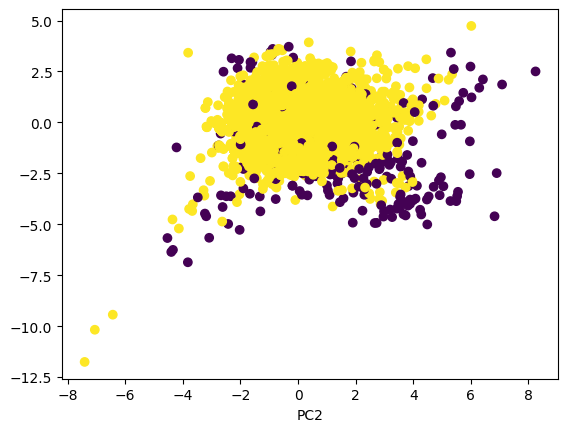

In [23]:
plt.Figure(figsize=(8,6))

plt.scatter(x=X_pca[:,0],y=X_pca[:,1],c=labels)
plt.xlabel("PC1")
plt.xlabel("PC2")

In [24]:
import numpy as np
print("number of outliers = ",np.sum(labels==-1))
print("number of normal points = ",np.sum(labels==1))

number of outliers =  249
number of normal points =  6667


### LOF

In [25]:
from sklearn.neighbors import LocalOutlierFactor

In [29]:
neighbs = LocalOutlierFactor(contamination=0.036)# yeha bhi contamination value define kar sakte hai yadi ham pahle se jante hai ki 3.6 percent values are outliers to we can define that here

labels = neighbs.fit_predict(X_scaled)

Text(0.5, 0, 'PC2')

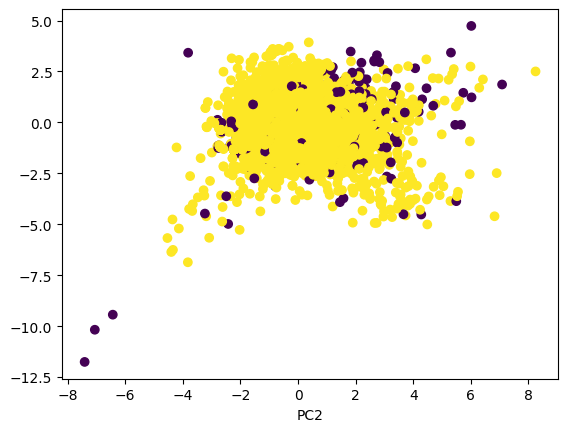

In [30]:
plt.Figure(figsize=(8,6))

plt.scatter(x=X_pca[:,0],y=X_pca[:,1],c=labels)
plt.xlabel("PC1")
plt.xlabel("PC2")

In [31]:
import numpy as np
print("number of outliers = ",np.sum(labels==-1))
print("number of normal points = ",np.sum(labels==1))

number of outliers =  249
number of normal points =  6667
